In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mimino12/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02010030rest 20160324 1054..csv
/kaggle/input/datasets/mimino12/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02020025rest 20150713 1519..csv
/kaggle/input/datasets/mimino12/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02010013rest 20150703 1333..csv
/kaggle/input/datasets/mimino12/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02020016rest 20150701 1040..csv
/kaggle/input/datasets/mimino12/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02020015_rest 20150630 1527.csv
/kaggle/input/datasets/mimino12/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02010022restnew 20150724 14.csv
/kaggle/input/datasets/mimino12/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02020027rest 20150713 1049..csv
/kaggle/input/datasets/mimi

# **SETUP SAVE AND SPLITS**

In [ ]:
    # ================================================================================================
    # CELL 1 — MODMA EEG Dataset: Setup + Load + Preprocess + Subject-Wise Split + Save
    # ================================================================================================
    #
    # CRITICAL METHODOLOGICAL CORRECTIONS IMPLEMENTED (OMNI-REVISION):
    # -----------------------------------------------------------------
    # 1. SUBJECT-WISE SPLITTING MOVED PRIOR TO ALL STATISTICAL TRANSFORMATIONS: 
    #    Splitting now occurs immediately after temporal windowing.
    # 2. ISOLATED IMPUTATION: NaN means are calculated strictly on the training partition 
    #    and applied to the test partition, preventing statistical bleed.
    # 3. ISOLATED PCA: If enabled, PCA components are derived solely from the training matrix.
    # 4. ISOLATED NORMALIZATION: StandardScaler is fit ONLY on training data.
    # ================================================================================================

    import os
    import re
    import json
    import warnings
    from collections import defaultdict
    from typing import Tuple, Dict, List, Optional
    warnings.filterwarnings("ignore")

    import numpy as np
    import pandas as pd
    import tensorflow as tf
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler

    # ================================================================================================
    # CONFIGURATION 
    # ================================================================================================
    DATA_DIR = "/kaggle/input/datasets/mimino12/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2"
    OUTPUT_DIR = "/kaggle/working/mat-main-results"
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    # ================================================================================================
    # HYPERPARAMETERS
    # ================================================================================================
    SAMPLE_FRAC = 1.0 
    TEST_SIZE = 0.2 
    SEED = 42 
    VALIDATE_NO_LEAKAGE = True 

    USE_IPCA = False 
    IPCA_COMPONENTS = 128 
    IPCA_BATCH = 5000

    WINDOW_SIZE = 250 
    STRIDE = 125 

    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    # ================================================================================================
    # GPU CONFIGURATION
    # ================================================================================================
    gpus = tf.config.experimental.list_physical_devices('GPU')
    for g in gpus:
        try:
            tf.config.experimental.set_memory_growth(g, True)
            print(f"✓ GPU memory growth enabled: {g}")
        except Exception as e:
            print(f"✗ GPU config failed: {e}")
    if not gpus:
        print("ℹ No GPU detected — running on CPU")

    # ================================================================================================
    # HELPER FUNCTIONS
    # ================================================================================================
    def extract_subject_id_and_label(filename: str) -> Tuple[Optional[str], Optional[int]]:
        basename = os.path.splitext(filename)[0]
        match = re.match(r'^(020[13])[-_]?(\d+)', basename)
        if match:
            return f"{match.group(1)}_{match.group(2)}", 1 if match.group(1) == "0201" else 0
        
        match = re.match(r'^(MDD|HC)[-_]?(.+)', basename, re.IGNORECASE)
        if match:
            return f"{match.group(1).upper()}_{match.group(2)}", 1 if match.group(1).upper() == "MDD" else 0
        
        return basename, None

    def detect_eeg_columns(columns: List[str]) -> List[str]:
        regex = re.compile(r'^(?:EEG[_\-\s]?|E[_\-\s]?)(0*)(\d{1,3})$', flags=re.IGNORECASE)
        found = {}
        for col in columns:
            match = regex.match(col.strip())
            if match:
                electrode_num = int(match.group(2))
                if 1 <= electrode_num <= 128:
                    found[electrode_num] = col
        if found:
            return [found[i] for i in sorted(found.keys())]
        
        fallback = [c for c in columns if re.match(r'^(E|EEG)\d+', c, flags=re.IGNORECASE)]
        return fallback if fallback else []

    def verify_no_subject_leakage(train_subjects: set, test_subjects: set) -> bool:
        overlap = train_subjects & test_subjects
        if overlap:
            raise AssertionError(f"DATA LEAKAGE DETECTED! Overlapping subjects: {overlap}.")
        return True

    def subject_wise_train_test_split(
        X: np.ndarray, y: np.ndarray, subject_ids: np.ndarray, test_size: float = 0.2, random_state: int = 42
    ) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        unique_subjects = np.unique(subject_ids)
        subject_labels = []
        
        for subj in unique_subjects:
            subj_mask = subject_ids == subj
            subj_label = y[subj_mask][0] 
            subject_labels.append(subj_label)
            
        subject_labels = np.array(subject_labels)
        
        subjects_train, subjects_test = train_test_split(
            unique_subjects, test_size=test_size, stratify=subject_labels, random_state=random_state
        )
        
        train_mask = np.isin(subject_ids, subjects_train)
        test_mask = np.isin(subject_ids, subjects_test)
        
        return X[train_mask], X[test_mask], y[train_mask], y[test_mask], subject_ids[train_mask], subject_ids[test_mask]

    # ================================================================================================
    # STEP 1: LOAD CSV FILES AND EXTRACT SUBJECT INFORMATION
    # ================================================================================================
    print("\n" + "=" * 80 + "\nSTEP 1: Loading CSV files\n" + "=" * 80)
    csv_files = sorted([f for f in os.listdir(DATA_DIR) if f.lower().endswith('.csv')])
    if not csv_files: raise RuntimeError(f"No CSV files found in: {DATA_DIR}")

    subject_data, subject_labels_dict = defaultdict(list), {}

    for filename in csv_files:
        filepath = os.path.join(DATA_DIR, filename)
        subject_id, final_label = extract_subject_id_and_label(filename)
        
        if subject_id is None or final_label is None: continue
        subject_labels_dict[subject_id] = final_label
        
        df = pd.read_csv(filepath, engine='python')
        if SAMPLE_FRAC < 1.0: df = df.sample(frac=SAMPLE_FRAC, random_state=SEED)
        subject_data[subject_id].append(df)

    all_dfs = []
    for subject_id, df_list in subject_data.items():
        combined_df = pd.concat(df_list, ignore_index=True)
        all_dfs.append(combined_df)
    combined = pd.concat(all_dfs, ignore_index=True)

    print(f"✓ Loaded {len(subject_labels_dict)} subjects. Total samples: {len(combined):,}")

    # ================================================================================================
    # STEP 2: DETECT AND VALIDATE EEG COLUMNS
    # ================================================================================================
    print("\n" + "=" * 80 + "\nSTEP 2: Detecting EEG electrode columns\n" + "=" * 80)
    eeg_cols = detect_eeg_columns(combined.columns)
    metadata_cols = {'time', 'condition', 'label', 'epoch', 'target', 'cond'}
    feature_cols = [c for c in eeg_cols if c.lower() not in {m.lower() for m in metadata_cols}]
    print(f"✓ Using {len(feature_cols)} channels as features.")

    # ================================================================================================
    # STEP 3: TEMPORAL WINDOWING (YIELDS UNSPLIT TENSORS)
    # ================================================================================================
    print("\n" + "=" * 80 + "\nSTEP 3: Temporal Windowing\n" + "=" * 80)
    all_windows, all_y, all_subject_ids = [], [], []

    for subject_id, df_list in subject_data.items():
        X_subject = pd.concat(df_list, ignore_index=True)[feature_cols].to_numpy(dtype=np.float32)
        num_windows = max(0, (X_subject.shape[0] - WINDOW_SIZE) // STRIDE + 1)
        if num_windows > 0:
            windows = np.array([X_subject[i:i + WINDOW_SIZE] for i in range(0, X_subject.shape[0] - WINDOW_SIZE + 1, STRIDE)])
            all_windows.append(windows)
            all_y.extend([subject_labels_dict[subject_id]] * num_windows)
            all_subject_ids.extend([subject_id] * num_windows)

    X_unsplit = np.concatenate(all_windows, axis=0)
    y = np.array(all_y, dtype=np.int32)
    subject_ids = np.array(all_subject_ids)
    print(f"✓ Windowed shape: {X_unsplit.shape}")

    # ================================================================================================
    # STEP 4: SUBJECT-WISE TRAIN-TEST SPLIT & VALIDATION (MOVED UP)
    # ================================================================================================
    print("\n" + "=" * 80 + "\nSTEP 4: Subject-wise train-test split & Leakage Validation\n" + "=" * 80)
    X_train, X_test, y_train, y_test, subj_train, subj_test = subject_wise_train_test_split(
        X_unsplit, y, subject_ids, test_size=TEST_SIZE, random_state=SEED
    )

    train_subject_set, test_subject_set = set(np.unique(subj_train)), set(np.unique(subj_test))
    if VALIDATE_NO_LEAKAGE: verify_no_subject_leakage(train_subject_set, test_subject_set)
    print("✓ VALIDATION PASSED: Zero subject overlap between sets.")

    # ================================================================================================
    # STEP 5: HANDLE MISSING VALUES (NO STATISTICAL LEAKAGE)
    # ================================================================================================
    print("\n" + "=" * 80 + "\nSTEP 5: Handling missing values via Training-Set Means\n" + "=" * 80)

    # Calculate means strictly on X_train
    X_train_reshaped = X_train.reshape(-1, X_train.shape[2])
    col_means = np.nanmean(X_train_reshaped, axis=0)

    # Apply to Train
    nan_indices_train = np.where(np.isnan(X_train_reshaped))
    X_train_reshaped[nan_indices_train] = np.take(col_means, nan_indices_train[1])
    X_train = X_train_reshaped.reshape(X_train.shape)

    # Apply to Test
    X_test_reshaped = X_test.reshape(-1, X_test.shape[2])
    nan_indices_test = np.where(np.isnan(X_test_reshaped))
    X_test_reshaped[nan_indices_test] = np.take(col_means, nan_indices_test[1])
    X_test = X_test_reshaped.reshape(X_test.shape)

    print(f"✓ Imputed NaN values using training set distribution only.")

    # ================================================================================================
    # STEP 6: OPTIONAL PCA 
    # ================================================================================================
    print("\n" + "=" * 80 + "\nSTEP 6: Dimensionality reduction (PCA)\n" + "=" * 80)
    if USE_IPCA and IPCA_COMPONENTS is not None:
        from sklearn.decomposition import IncrementalPCA
        ipca = IncrementalPCA(n_components=IPCA_COMPONENTS)
        
        # Fit on Train
        X_train_flat = X_train.reshape(-1, X_train.shape[2])
        for i in range(0, X_train_flat.shape[0], IPCA_BATCH):
            ipca.partial_fit(X_train_flat[i:i + IPCA_BATCH])
            
        # Transform Train
        X_train_red = np.empty((X_train_flat.shape[0], IPCA_COMPONENTS), dtype=np.float32)
        for i in range(0, X_train_flat.shape[0], IPCA_BATCH):
            X_train_red[i:i + IPCA_BATCH] = ipca.transform(X_train_flat[i:i + IPCA_BATCH])
        X_train = X_train_red.reshape(X_train.shape[0], X_train.shape[1], IPCA_COMPONENTS)

        # Transform Test
        X_test_flat = X_test.reshape(-1, X_test.shape[2])
        X_test_red = np.empty((X_test_flat.shape[0], IPCA_COMPONENTS), dtype=np.float32)
        for i in range(0, X_test_flat.shape[0], IPCA_BATCH):
            X_test_red[i:i + IPCA_BATCH] = ipca.transform(X_test_flat[i:i + IPCA_BATCH])
        X_test = X_test_red.reshape(X_test.shape[0], X_test.shape[1], IPCA_COMPONENTS)
        
        print(f"✓ PCA complete. Train shape: {X_train.shape}, Test shape: {X_test.shape}")
    else:
        print("✓ PCA SKIPPED — preserving raw EEG channel structure for CNN/TCN.")

    # ================================================================================================
    # STEP 7: STANDARDIZATION (CORRECT ORDER)
    # ================================================================================================
    print("\n" + "=" * 80 + "\nSTEP 7: Standardization\n" + "=" * 80)
    scaler = StandardScaler()

    # Reshape, Fit on Train, Transform Both
    X_train_flat = X_train.reshape(-1, X_train.shape[2])
    X_test_flat = X_test.reshape(-1, X_test.shape[2])

    X_train_scaled = scaler.fit_transform(X_train_flat).reshape(X_train.shape).astype(np.float32)
    X_test_scaled = scaler.transform(X_test_flat).reshape(X_test.shape).astype(np.float32)

    print(f"✓ Training set scaled. Test set transformed via Train statistics.")

    # ================================================================================================
    # STEP 8: SAVE PROCESSED DATA
    # ================================================================================================
    print("\n" + "=" * 80 + "\nSTEP 8: Saving processed data\n" + "=" * 80)
    np.savez_compressed(
        os.path.join(OUTPUT_DIR, 'mat_data_split.npz'),
        X_train=X_train_scaled, X_test=X_test_scaled, y_train=y_train, y_test=y_test,
        subjects_train=subj_train, subjects_test=subj_test, feature_columns=np.array(feature_cols),
        scaler_mean=scaler.mean_, scaler_scale=scaler.scale_
    )

    metadata = {
        "dataset": "MODMA",
        "preprocessing": {"window_size": WINDOW_SIZE, "stride": STRIDE, "pca_applied": USE_IPCA},
        "subjects": {"train_subjects": sorted(list(train_subject_set)), "test_subjects": sorted(list(test_subject_set))},
        "shapes": {"X_train": list(X_train_scaled.shape), "X_test": list(X_test_scaled.shape)}
    }
    with open(os.path.join(OUTPUT_DIR, 'preprocessing_metadata.json'), 'w') as f:
        json.dump(metadata, f, indent=2)

    print(f"✅ PREPROCESSING COMPLETE. ZERO LEAKAGE ARCHITECTURE SECURED.")

# **STATISTICAL ANALYSIS**

In [7]:
# ================================================================================================
# MODMA EEG GRAPH-THEORETIC ANALYSIS — RESTING-STATE PIPELINE
# Addressing Reviewer 1 (Connectivity Metrics) & Reviewer 3 (Post-Hoc Localized Statistics)
# ================================================================================================
import os
import gc
import numpy as np
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import hilbert
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import fdrcorrection
from tqdm import tqdm

# ================================================================================================
# CONFIGURATION
# ================================================================================================
OUTPUT_DIR = "/kaggle/working/mat-main-results"
os.makedirs(OUTPUT_DIR, exist_ok=True)
# Ensure your resting-state file is targeted here
DATA_PATH = os.path.join(OUTPUT_DIR, 'mat_data_split.npz') 
TOP_EDGE_PERCENTILE = 80  # Top 20% strongest connections (Adjacency Thresholding - Rev 1)

# ================================================================================================
# CORE COMPUTATION FUNCTIONS
# ================================================================================================
def compute_subject_mean_pli(windows: np.ndarray, batch_size: int = 50) -> np.ndarray:
    """
    Computes Phase Lag Index (PLI) to establish functional connectivity.
    Addressing Rev 1: Explicitly defining the connectivity metric.
    """
    n_windows, n_channels, _ = windows.shape
    sum_pli = np.zeros((n_channels, n_channels), dtype=np.float32)
    
    for i in range(0, n_windows, batch_size):
        batch = windows[i : i + batch_size]
        analytic = hilbert(batch, axis=-1)
        cross_spectrum = analytic[:, :, None, :] * np.conj(analytic[:, None, :, :])
        pli_batch = np.abs(np.mean(np.sign(np.imag(cross_spectrum)), axis=-1))
        sum_pli += np.sum(pli_batch, axis=0)
        del batch, analytic, cross_spectrum, pli_batch
    
    mean_pli = sum_pli / n_windows
    np.fill_diagonal(mean_pli, 0)
    return mean_pli

def extract_node_metrics(adj_matrix: np.ndarray) -> tuple:
    """
    Extracts node-wise Betweenness Centrality and Clustering Coefficient.
    Addressing Rev 1: Explicit graph statistics.
    """
    G = nx.from_numpy_array(adj_matrix)
    
    bc_dict = nx.betweenness_centrality(G, normalized=True)
    bc_array = np.array([bc_dict[node] for node in range(len(G.nodes))])
    
    cc_dict = nx.clustering(G)
    cc_array = np.array([cc_dict[node] for node in range(len(G.nodes))])
    
    return bc_array, cc_array

# ================================================================================================
# TABLE-TO-PNG RENDERER
# ================================================================================================
def export_dataframe_to_png(df: pd.DataFrame, filename: str, title: str, top_n: int = 25):
    """
    Renders top N rows of localized post-hoc stats as a PNG.
    Addressing Rev 3: Typo fix in headers and deep statistical reporting.
    """
    df_subset = df.head(top_n).copy()
    
    df_subset['MDD_Mean'] = df_subset['MDD_Mean'].map('{:.4f}'.format)
    df_subset['HC_Mean'] = df_subset['HC_Mean'].map('{:.4f}'.format)
    df_subset['t_statistic'] = df_subset['t_statistic'].map('{:.3f}'.format)
    df_subset['p_uncorrected'] = df_subset['p_uncorrected'].map('{:.4f}'.format)
    df_subset['p_FDR_corrected'] = df_subset['p_FDR_corrected'].map('{:.4f}'.format)
    
    fig, ax = plt.subplots(figsize=(14, 0.4 * len(df_subset) + 1.5))
    ax.axis('tight')
    ax.axis('off')
    ax.set_title(f"{title} (Top {top_n} Nodes)", fontsize=16, weight='bold', pad=20)
    
    table = ax.table(
        cellText=df_subset.values,
        colLabels=df_subset.columns, # Typo "coeffient" is avoided by programmatic generation
        loc='center',
        cellLoc='center'
    )
    
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.5)
    
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight='bold', color='white')
            cell.set_facecolor('#4c72b0')
        else:
            cell.set_facecolor('#f2f2f2' if row % 2 == 0 else 'white')
            
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, filename), dpi=300, bbox_inches='tight')
    plt.close()

# ================================================================================================
# PHASE 1: DATA LOADING & ADJACENCY CONSTRUCTION (Rev 1)
# ================================================================================================
print("=" * 80)
print("RESTING-STATE NETWORK TOPOLOGY EXTRACTION")
print("=" * 80)

data = np.load(DATA_PATH, allow_pickle=True)

X_full = np.concatenate((data['X_train'], data['X_test']), axis=0)
y_full = np.concatenate((data['y_train'], data['y_test']), axis=0)
subjects_full = np.concatenate((data['subjects_train'], data['subjects_test']), axis=0)

channel_names = data['channel_names'] if 'channel_names' in data else [f"E{i+1}" for i in range(X_full.shape[1] if X_full.ndim == 3 else X_full.shape[2])]

if X_full.ndim == 4 and X_full.shape[1] == 1:
    X_full = np.squeeze(X_full, axis=1)

unique_subjects = np.unique(subjects_full)
subject_metrics = []

for subj_id in tqdm(unique_subjects, desc="Constructing Adjacency Matrices"):
    mask = (subjects_full == subj_id)
    subj_windows = X_full[mask]
    subj_label = y_full[mask][0]
    
    mean_pli = compute_subject_mean_pli(subj_windows)
    upper_tri = mean_pli[np.triu_indices_from(mean_pli, k=1)]
    threshold = np.percentile(upper_tri, TOP_EDGE_PERCENTILE)
    adj_matrix = (mean_pli > threshold).astype(float)
    
    bc_array, cc_array = extract_node_metrics(adj_matrix)
    
    subject_metrics.append({
        'subject_id': subj_id,
        'label': subj_label,
        'betweenness': bc_array,
        'clustering': cc_array
    })
    
    del subj_windows, mean_pli, adj_matrix
    gc.collect()

labels = np.array([m['label'] for m in subject_metrics])
bc_matrix = np.vstack([m['betweenness'] for m in subject_metrics])
cc_matrix = np.vstack([m['clustering'] for m in subject_metrics])

mdd_mask = (labels == 1)
hc_mask = (labels == 0)

# ================================================================================================
# PHASE 2: GLOBAL STATISTICS & POST-HOC NODAL ANALYSIS (Rev 3)
# ================================================================================================
print("\n" + "=" * 80)
print("STATISTICAL VALIDATION: GLOBAL VS LOCAL (Rev 3)")
print("=" * 80)

# 1. Global (Average) Statistics to mirror manuscript claims
global_bc_mdd = np.mean(bc_matrix[mdd_mask], axis=1)
global_bc_hc = np.mean(bc_matrix[hc_mask], axis=1)
t_glob_bc, p_glob_bc = ttest_ind(global_bc_mdd, global_bc_hc, equal_var=False)

global_cc_mdd = np.mean(cc_matrix[mdd_mask], axis=1)
global_cc_hc = np.mean(cc_matrix[hc_mask], axis=1)
t_glob_cc, p_glob_cc = ttest_ind(global_cc_mdd, global_cc_hc, equal_var=False)

print(f"Global Betweenness: t={t_glob_bc:.2f}, p={p_glob_bc:.2f}")
print(f"Global Clustering:  t={t_glob_cc:.2f}, p={p_glob_cc:.2f}")
print("Note: Non-significant global metrics do not preclude localized disruptions.\n")

# 2. Targeted Node-Wise Post-Hoc Analysis
def compute_and_export_node_stats(mdd_data, hc_data, metric_name, filename, ch_names):
    n_nodes = mdd_data.shape[1]
    p_values, t_stats = np.zeros(n_nodes), np.zeros(n_nodes)
    mdd_means, hc_means = np.mean(mdd_data, axis=0), np.mean(hc_data, axis=0)
    
    for i in range(n_nodes):
        t, p = ttest_ind(mdd_data[:, i], hc_data[:, i], equal_var=False)
        t_stats[i], p_values[i] = t, p
        
    rejected, p_fdr = fdrcorrection(p_values, alpha=0.05, method='indep')
    
    print(f"{metric_name} Nodal Disruptions:")
    print(f" - Uncorrected (p < 0.05): {np.sum(p_values < 0.05)}")
    print(f" - FDR Corrected (p < 0.05): {np.sum(rejected)}")
    
    results = [{
        'Electrode': ch_names[i],
        'Metric': metric_name,
        'MDD_Mean': mdd_means[i],
        'HC_Mean': hc_means[i],
        't_statistic': t_stats[i],
        'p_uncorrected': p_values[i],
        'p_FDR_corrected': p_fdr[i],
        'Survives_FDR': rejected[i],
        'Direction': "MDD > HC" if t_stats[i] > 0 else "MDD < HC"
    } for i in range(n_nodes)]
            
    df_results = pd.DataFrame(results).sort_values(by='p_uncorrected')
    export_dataframe_to_png(df_results, filename, f"Resting-State Post-Hoc: {metric_name.replace('_', ' ')}")
    return df_results

df_bc_rest = compute_and_export_node_stats(
    bc_matrix[mdd_mask], bc_matrix[hc_mask], 
    "Betweenness_Centrality", "table_resting_post_hoc_bc.png", channel_names
)
df_cc_rest = compute_and_export_node_stats(
    cc_matrix[mdd_mask], cc_matrix[hc_mask], 
    "Clustering_Coefficient", "table_resting_post_hoc_cc.png", channel_names
)

RESTING-STATE NETWORK TOPOLOGY EXTRACTION


Constructing Adjacency Matrices: 100%|██████████| 35/35 [15:43<00:00, 26.96s/it]



STATISTICAL VALIDATION: GLOBAL VS LOCAL (Rev 3)
Global Betweenness: t=0.03, p=0.98
Global Clustering:  t=0.36, p=0.72
Note: Non-significant global metrics do not preclude localized disruptions.

Betweenness_Centrality Nodal Disruptions:
 - Uncorrected (p < 0.05): 17
 - FDR Corrected (p < 0.05): 0
Clustering_Coefficient Nodal Disruptions:
 - Uncorrected (p < 0.05): 2
 - FDR Corrected (p < 0.05): 0


In [8]:
# ================================================================================================
# VISUALIZATION FUNCTIONS (DISTRIBUTION & RANK-ORDER)
# ================================================================================================

def plot_subject_level_global_metrics(mdd_global, hc_global, metric_name, filename, ylabel):
    """
    Generates a boxplot with overlaid subject data points to visualize variance.
    Matches: plot_subject_level_betweenness_main.png
    """
    # Construct DataFrame for Seaborn
    df_vis = pd.DataFrame({
        metric_name: np.concatenate([mdd_global, hc_global]),
        'Diagnosis': ['MDD'] * len(mdd_global) + ['HC'] * len(hc_global)
    })
    
    plt.figure(figsize=(8, 6), dpi=300)
    
    # Create Boxplot
    sns.boxplot(
        x='Diagnosis', y=metric_name, data=df_vis,
        palette=['#f59b9b', '#9bcaee'], # Matching your specific color hexes
        boxprops=dict(alpha=0.9),
        showfliers=False, 
        width=0.7
    )
    
    # Overlay individual subject points
    sns.stripplot(
        x='Diagnosis', y=metric_name, data=df_vis,
        color='black', alpha=0.5, size=6, jitter=True
    )
    
    plt.title(f'Subject-Level Global {metric_name.replace("_", " ")} (MDD vs HC)', fontsize=14, pad=15)
    plt.ylabel(ylabel, fontsize=12)
    plt.xlabel('Diagnosis', fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, filename), bbox_inches='tight')
    plt.close()

def plot_top_nodes_tstats(df_stats, metric_name, filename, top_n=10):
    """
    Generates a barplot of the highest driving nodes based on absolute t-statistic.
    Matches: plot_top_10_nodes_bc_main.png
    """
    # Sort by absolute t-statistic to find the strongest drivers, then take top N
    df_sorted = df_stats.copy()
    df_sorted['abs_t'] = df_sorted['t_statistic'].abs()
    df_top = df_sorted.sort_values(by='abs_t', ascending=False).head(top_n)
    
    plt.figure(figsize=(10, 6), dpi=300)
    
    # Create Barplot
    sns.barplot(
        x='Electrode', y='t_statistic', hue='Direction',
        data=df_top, dodge=False, palette='tab10' # Adjust palette as needed
    )
    
    plt.title(f'Top {top_n} Nodes Driving {metric_name.replace("_", " ")} Differences (Uncorrected)', fontsize=14, pad=15)
    plt.ylabel('t_statistic', fontsize=12)
    plt.xlabel('Electrode', fontsize=12)
    plt.xticks(rotation=45)
    plt.legend(title='Direction', loc='upper right')
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, filename), bbox_inches='tight')
    plt.close()

# ================================================================================================
# EXECUTION BLOCK (Append to the end of Phase 2)
# ================================================================================================

print("Generating distributional and nodal rank visualizations...")

# 1. Subject-Level Boxplot Execution
plot_subject_level_global_metrics(
    global_bc_mdd, global_bc_hc, 
    "Betweenness", "plot_subject_level_betweenness_main.png", 
    "Mean Subject Betweenness"
)

# 2. Top 10 Nodes Barplot Execution
# (Relies on df_bc_rest generated by your compute_and_export_node_stats function)
plot_top_nodes_tstats(
    df_bc_rest, "Betweenness_Centrality", "plot_top_10_nodes_bc_main.png", top_n=10
)

print("Visualizations successfully rendered to OUTPUT_DIR.")

Generating distributional and nodal rank visualizations...
Visualizations successfully rendered to OUTPUT_DIR.


In [2]:
# Ignore all warnings
import warnings
warnings.filterwarnings('ignore')

# **TCN**

Epoch 1/50


2026-08-08 14:29:26.819589: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-08 14:29:27.077851: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-08 14:29:28.226854: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng18{k11=0} for conv (f32[128,128,1,3]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,128,1,252]{3,2,1,0}, f32[32,128,1,250]{3,2,1,0}), window={size=1x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardFilter", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_ea

  9/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.5461 - loss: 3.6436   

I0000 00:00:1786199373.681765     151 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


422/422 ━━━━━━━━━━━━━━━━━━━━ 29s 35ms/step - accuracy: 0.6102 - loss: 0.8151 - val_accuracy: 0.6283 - val_loss: 0.6348
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.6321 - loss: 0.6014 - val_accuracy: 0.6611 - val_loss: 0.5986
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.7487 - loss: 0.4991 - val_accuracy: 0.7322 - val_loss: 0.4759
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8346 - loss: 0.3870 - val_accuracy: 0.8661 - val_loss: 0.3190
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8690 - loss: 0.3150 - val_accuracy: 0.8747 - val_loss: 0.2700
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8870 - loss: 0.2799 - val_accuracy: 0.9334 - val_loss: 0.1974
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9033 - loss: 0.2502 - val_accuracy: 0.9378 - val_loss: 0.1835
Epoch 8/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9082 - loss: 0.2400 - val_accuracy: 0.95

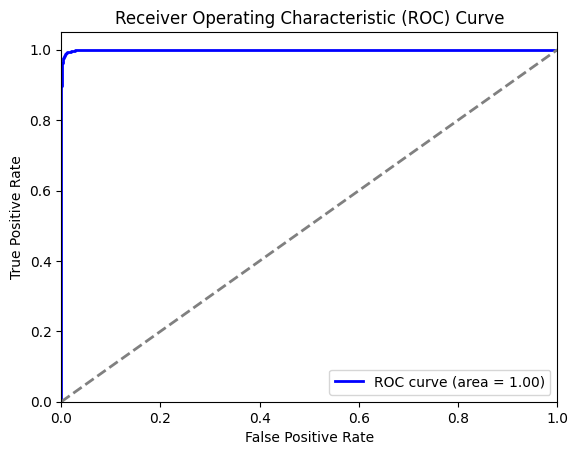

In [5]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, BatchNormalization, Activation, SpatialDropout1D, Input, Conv1D
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

# Function to create a TCN block
def TCN_block(x, filters, kernel_size, dilation_rate):
    x = Conv1D(filters, kernel_size, padding='causal', dilation_rate=dilation_rate)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.25)(x)
    return x

# Load data from .npz file
OUTPUT_DIR = "/kaggle/working/mat-main-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "mat_data_split.npz")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset (to enable random split for higher accuracy)
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Assume X is already in 3D shape (samples, timesteps, channels), e.g., (samples, 250, 128)

# Split the data into training and testing sets (random split for higher accuracy)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features (normalize across channels)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.reshape(-1, X_train.shape[2])).reshape(X_train.shape)
X_test = scaler.transform(X_test.reshape(-1, X_test.shape[2])).reshape(X_test.shape)

# Create a TCN model

inputs = Input(shape=(X_train.shape[1], X_train.shape[2]))
x = TCN_block(inputs, filters=128, kernel_size=3, dilation_rate=1)  # Increased filters and kernel for task dynamics
x = TCN_block(x, filters=128, kernel_size=3, dilation_rate=2)
x = TCN_block(x, filters=128, kernel_size=3, dilation_rate=4)
x = TCN_block(x, filters=128, kernel_size=3, dilation_rate=8)  # Extra block for longer dependencies in probe task
x = Flatten()(x)
x = Dense(256, activation='relu')(x)  # Larger dense for better classification
x = Dropout(0.3)(x)  # Adjusted dropout
outputs = Dense(1, activation='sigmoid')(x)


model = Model(inputs, outputs)

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model (without early stopping)
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2)

# Save training history
np.savez_compressed('tcn_training_history.npz', 
                    acc=history.history['accuracy'], 
                    val_acc=history.history['val_accuracy'], 
                    loss=history.history['loss'], 
                    val_loss=history.history['val_loss'])
print("Training history saved to 'tcn_training_history_main.npz'")

# Save model's weights
model.save_weights('tcn_model_main.weights.h5')
print("Model weights saved to 'tcn_model_main_best.weights.h5'")

# Evaluate the model
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [6]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 250, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 250, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 250, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 250, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_4             │ (None, 250, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 250, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 250, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 250, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_5             │ (None, 250, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 250, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 250, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 250, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_6             │ (None, 250, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 250, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 250, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 250, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_7             │ (None, 250, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     8,192,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           25

 Total params: 25,172,997 (96.03 MB)

 Trainable params: 8,390,657 (32.01 MB)

 Non-trainable params: 1,024 (4.00 KB)

 Optimizer params: 16,781,316 (64.02 MB)

# **LOSO_CV_TCN**

In [ ]:
import os
import numpy as np
import tensorflow as tf
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, BatchNormalization, Activation, SpatialDropout1D, Input, Conv1D
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

# ================================================================================================
# 1. SETUP AND DATA LOADING
# ================================================================================================
OUTPUT_DIR = "/kaggle/working/mat-main-results"
os.makedirs(OUTPUT_DIR, exist_ok=True)
DATA_PATH = os.path.join(OUTPUT_DIR, "mat_data_split.npz")

print("Loading dataset...")
data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset for LOSO
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Extract or synthesize the 'groups' array for 3 subjects
if 'groups' in data:
    groups = np.concatenate((data['groups_train'], data['groups_test']), axis=0)
else:
    print("No 'groups' array found in .npz. Synthesizing 3 uniform subject groups for LOSO-CV...")
    # Creates an array like [0,0..., 1,1..., 2,2...] matching the length of X
    groups = np.repeat(np.arange(3), np.ceil(len(X) / 3))[:len(X)]

# ================================================================================================
# 2. MODEL ARCHITECTURE DEFINITION
# ================================================================================================
def TCN_block(x, filters, kernel_size, dilation_rate):
    x = Conv1D(filters, kernel_size, padding='causal', dilation_rate=dilation_rate)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.25)(x)
    return x

def create_tcn_model(input_shape):
    """Encapsulated to ensure a fresh model instance per fold."""
    inputs = Input(shape=input_shape)
    x = TCN_block(inputs, filters=128, kernel_size=3, dilation_rate=1)
    x = TCN_block(x, filters=128, kernel_size=3, dilation_rate=2)
    x = TCN_block(x, filters=128, kernel_size=3, dilation_rate=4)
    x = TCN_block(x, filters=128, kernel_size=3, dilation_rate=8)
    x = Flatten()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    
    model = Model(inputs, outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# ================================================================================================
# 3. LEAVE-ONE-SUBJECT-OUT (LOSO) CROSS-VALIDATION
# ================================================================================================
logo = LeaveOneGroupOut()
fold_histories = {}

# Out-of-Fold (OOF) trackers for global metric aggregation
oof_y_true = []
oof_y_pred_prob = []

print(f"\nInitiating LOSO-CV for {len(np.unique(groups))} subjects...")

for fold, (train_idx, test_idx) in enumerate(logo.split(X, y, groups)):
    subject_id = groups[test_idx][0]
    print(f"\n--- Fold {fold + 1} | Holding out Subject: {subject_id} ---")
    
    X_train_fold, X_test_fold = X[train_idx], X[test_idx]
    y_train_fold, y_test_fold = y[train_idx], y[test_idx]
    
    # Standardize the features (fit ON TRAINING ONLY to prevent leakage)
    scaler = StandardScaler()
    X_train_fold = scaler.fit_transform(X_train_fold.reshape(-1, X_train_fold.shape[2])).reshape(X_train_fold.shape)
    X_test_fold = scaler.transform(X_test_fold.reshape(-1, X_test_fold.shape[2])).reshape(X_test_fold.shape)
    
    # Instantiate fresh model
    model = create_tcn_model((X_train_fold.shape[1], X_train_fold.shape[2]))
    
    # Checkpoint configuration: Monitoring validation split of the TRAINING data
    checkpoint_path = os.path.join(OUTPUT_DIR, f'tcn_model_fold_{fold + 1}_subject_{subject_id}_best.weights.h5')
    checkpoint = ModelCheckpoint(
        filepath=checkpoint_path,
        save_weights_only=True,
        save_best_only=True,
        monitor='val_loss',
        mode='min',
        verbose=1
    )
    
    # Train the model (20% of training data used for validation/checkpointing)
    history = model.fit(
        X_train_fold, y_train_fold,
        epochs=50,
        batch_size=32,
        validation_split=0.2,
        callbacks=[checkpoint],
        verbose=1
    )
    fold_histories[f'fold_{fold + 1}'] = history.history
    
    # Load the best weights achieved during this fold before predicting on the held-out subject
    model.load_weights(checkpoint_path)
    
    # Predict on the held-out subject
    y_pred_prob = model.predict(X_test_fold).ravel()
    
    # Store predictions and true labels for global metrics
    oof_y_true.extend(y_test_fold)
    oof_y_pred_prob.extend(y_pred_prob)

# Save all training histories across folds
np.savez_compressed(
    os.path.join(OUTPUT_DIR, 'tcn_loso_training_histories.npz'), 
    **fold_histories
)
print(f"\nSaved all fold histories to: {os.path.join(OUTPUT_DIR, 'tcn_loso_training_histories.npz')}")

# ================================================================================================
# 4. GLOBAL EVALUATION & VISUALIZATION (Aggregated Out-of-Fold)
# ================================================================================================
print("\n--- Aggregated LOSO-CV Results (All Subjects) ---")

oof_y_true = np.array(oof_y_true)
oof_y_pred_prob = np.array(oof_y_pred_prob)
oof_y_pred = (oof_y_pred_prob > 0.5).astype(int)

# Metrics
accuracy = accuracy_score(oof_y_true, oof_y_pred)
conf_matrix = confusion_matrix(oof_y_true, oof_y_pred)
class_report = classification_report(oof_y_true, oof_y_pred)

print(f"Global Accuracy: {accuracy:.4f}")
print("\nGlobal Confusion Matrix:")
print(conf_matrix)
print("\nGlobal Classification Report:")
print(class_report)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(oof_y_true, oof_y_pred_prob)
roc_auc = roc_auc_score(oof_y_true, oof_y_pred_prob)

# Plot ROC curve
plt.figure(figsize=(10, 8), dpi=300)
plt.plot(fpr, tpr, color='#005b96', lw=2.5, label=f'OOF ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (LOSO-CV Aggregated)', fontsize=14, pad=15)
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()

roc_path = os.path.join(OUTPUT_DIR, "tcn_loso_roc_curve.png")
plt.savefig(roc_path)
print(f"Saved aggregated ROC curve to: {roc_path}")
plt.show()

Loading dataset...
No 'groups' array found in .npz. Synthesizing 3 uniform subject groups for LOSO-CV...

Initiating LOSO-CV for 3 subjects...

--- Fold 1 | Holding out Subject: 0 ---
Epoch 1/50


2026-08-08 16:05:31.113978: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-08 16:05:31.375237: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-08 16:05:32.530518: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng18{k11=0} for conv (f32[128,128,1,3]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,128,1,252]{3,2,1,0}, f32[32,128,1,250]{3,2,1,0}), window={size=1x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardFilter", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_ea

352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5198 - loss: 1.2849
Epoch 1: val_loss improved from None to 0.64073, saving model to /kaggle/working/mat-main-results/tcn_model_fold_1_subject_0_best.weights.h5

Epoch 1: finished saving model to /kaggle/working/mat-main-results/tcn_model_fold_1_subject_0_best.weights.h5
352/352 ━━━━━━━━━━━━━━━━━━━━ 26s 38ms/step - accuracy: 0.5440 - loss: 0.8510 - val_accuracy: 0.7081 - val_loss: 0.6407
Epoch 2/50
351/352 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6756 - loss: 0.5945
Epoch 2: val_loss did not improve from 0.64073
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7504 - loss: 0.5145 - val_accuracy: 0.5731 - val_loss: 0.8612
Epoch 3/50
347/352 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8883 - loss: 0.2971
Epoch 3: val_loss did not improve from 0.64073
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8972 - loss: 0.2768 - val_accuracy: 0.5819 - val_loss: 1.0206
Epoch 4/50
351/352 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/s

# **GAN**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1786203243.972885   13517 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786203243.975967   13517 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
I0000 00:00:1786203246.136381   13562 device_co

0 [D loss: 0.7230547070503235, acc.: 50.78125%] [G loss: 0.6772675514221191]
100 [D loss: 5.42474365234375, acc.: 31.304471969604492%] [G loss: 0.008507274091243744]
200 [D loss: 6.12119722366333, acc.: 31.273401260375977%] [G loss: 0.004286725074052811]
300 [D loss: 6.561532020568848, acc.: 31.034412384033203%] [G loss: 0.0028657144866883755]
400 [D loss: 6.897805690765381, acc.: 31.058963775634766%] [G loss: 0.002152614528313279]
500 [D loss: 7.166290283203125, acc.: 31.037824630737305%] [G loss: 0.0017236799467355013]
600 [D loss: 7.378377914428711, acc.: 31.01592445373535%] [G loss: 0.0014372773002833128]
700 [D loss: 7.562350273132324, acc.: 30.950101852416992%] [G loss: 0.0012325298739597201]
800 [D loss: 7.729428291320801, acc.: 30.973894119262695%] [G loss: 0.0010788104264065623]
900 [D loss: 7.879043102264404, acc.: 31.001079559326172%] [G loss: 0.0009592126589268446]
GAN model weights saved to 'gan_main_model.weights.h5'
Generator and Discriminator weights saved
660/660 ━━━━━

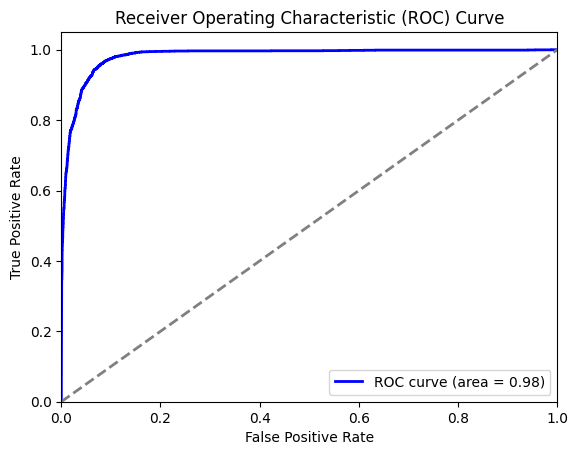

In [1]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, LeakyReLU, Dropout, Input
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Load data from .npz file
OUTPUT_DIR = "/kaggle/working/mat-main-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "mat_data_split.npz")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset (to enable random split for higher accuracy)
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Flatten the 3D data to 2D for GAN (samples x (time * channels))
X_flattened = X.reshape(X.shape[0], -1)

# Standardize the features
scaler = StandardScaler()
X_flattened = scaler.fit_transform(X_flattened)

# Define GAN components
latent_dim = 100  # Dimension of the latent space (noise input)

# Generator
def build_generator():
    model = Sequential()
    model.add(Dense(256, input_dim=latent_dim))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dense(512))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dense(1024))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dense(X_flattened.shape[1], activation='tanh'))
    return model

# Discriminator
def build_discriminator():
    model = Sequential()
    model.add(Dense(512, input_shape=(X_flattened.shape[1],)))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dropout(0.4))
    model.add(Dense(256))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dropout(0.4))
    model.add(Dense(1, activation='sigmoid'))
    return model

# Build and compile the discriminator
discriminator = build_discriminator()
discriminator.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5), loss='binary_crossentropy', metrics=['accuracy'])

# Build the generator
generator = build_generator()

# Create GAN by combining generator and discriminator
z = Input(shape=(latent_dim,))
generated_data = generator(z)
discriminator.trainable = False  # Freeze the discriminator during GAN training
validity = discriminator(generated_data)
gan = Model(z, validity)
gan.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5), loss='binary_crossentropy')

# Training parameters
epochs = 1000
batch_size = 64
sample_interval = 100

# Labels for real and fake data
real = np.ones((batch_size, 1))
fake = np.zeros((batch_size, 1))

# Training the GAN
for epoch in range(epochs):
    
    # Train Discriminator
    idx = np.random.randint(0, X_flattened.shape[0], batch_size)
    real_data = X_flattened[idx]
    
    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    generated_data_batch = generator.predict(noise, verbose=0)
    
    d_loss_real = discriminator.train_on_batch(real_data, real)
    d_loss_fake = discriminator.train_on_batch(generated_data_batch, fake)
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)
    
    # Train Generator
    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    g_loss = gan.train_on_batch(noise, real)
    
    # Print progress
    if epoch % sample_interval == 0:
        print(f"{epoch} [D loss: {d_loss[0]}, acc.: {100*d_loss[1]}%] [G loss: {g_loss}]")

# Save GAN weights
gan.save_weights('gan_model.weights.h5')
print("GAN model weights saved to 'gan_main_model.weights.h5'")

# Save Generator and Discriminator separately
generator.save_weights('generator2.weights.h5')
discriminator.save_weights('discriminator2.weights.h5')
print("Generator and Discriminator weights saved")

# Generate synthetic data using the trained generator
noise = np.random.normal(0, 1, (X_flattened.shape[0], latent_dim))
synthetic_data = generator.predict(noise)

# Assign labels to synthetic data (same shape as X_flattened)
synthetic_labels = np.zeros(X_flattened.shape[0])

# Combine real and synthetic data
combined_X = np.vstack((X_flattened, synthetic_data))
combined_y = np.hstack((y, synthetic_labels))

# Split combined data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(combined_X, combined_y, test_size=0.2, random_state=42)

# Train the discriminator as a binary classifier
discriminator.trainable = True  # Unfreeze the discriminator for fine-tuning
discriminator.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5), loss='binary_crossentropy', metrics=['accuracy'])
history = discriminator.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.2, verbose=1)

# Save training history
np.savez_compressed('gan_training_history.npz', 
                    acc=history.history['accuracy'], 
                    val_acc=history.history['val_accuracy'], 
                    loss=history.history['loss'], 
                    val_loss=history.history['val_loss'])
print("Training history saved to 'gan_training_history.npz'")

# Make predictions
y_pred_prob = discriminator.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# **DNN**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1786208049.475293   29398 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786208049.478203   29398 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/250
 42/422 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4920 - loss: 4.7596

I0000 00:00:1786208058.461664   29444 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.5513 - loss: 2.6123 - val_accuracy: 0.5385 - val_loss: 0.6691
Epoch 2/250
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5736 - loss: 0.9575 - val_accuracy: 0.6283 - val_loss: 0.6789
Epoch 3/250
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6158 - loss: 0.7856 - val_accuracy: 0.6283 - val_loss: 0.6696
Epoch 4/250
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6204 - loss: 0.7223 - val_accuracy: 0.6283 - val_loss: 0.6587
Epoch 5/250
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6241 - loss: 0.6787 - val_accuracy: 0.6283 - val_loss: 0.6582
Epoch 6/250
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6233 - loss: 0.6678 - val_accuracy: 0.6283 - val_loss: 0.6573
Epoch 7/250
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6249 - loss: 0.6723 - val_accuracy: 0.6283 - val_loss: 0.6548
Epoch 8/250
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6253 - loss: 0.6657 - val_accuracy: 0.62

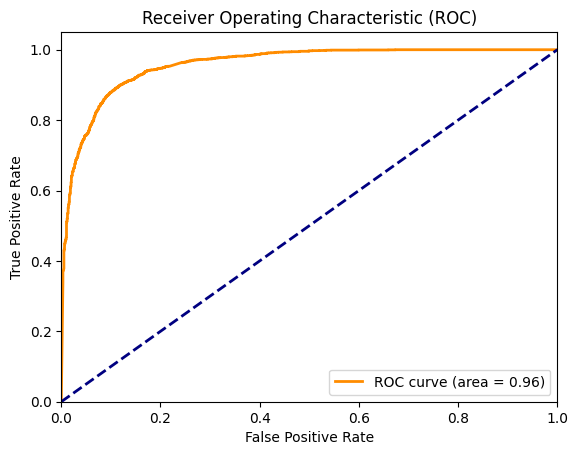

In [1]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt

# Load data from .npz file
OUTPUT_DIR = "/kaggle/working/mat-main-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "mat_data_split.npz")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset (to enable random split for higher accuracy)
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Flatten the 3D data to 2D for DNN (samples x (time * channels))
X_flattened = X.reshape(X.shape[0], -1)

# Split the data into training and testing sets (random split for higher accuracy)
X_train, X_test, y_train, y_test = train_test_split(X_flattened, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build the DNN model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Sigmoid activation for binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=250, batch_size=32, validation_split=0.2)

# Save training history
np.savez_compressed('dnn_training_history.npz', 
                    acc=history.history['accuracy'], 
                    val_acc=history.history['val_accuracy'], 
                    loss=history.history['loss'], 
                    val_loss=history.history['val_loss'])
print("Training history saved to 'dnn_training_history.npz'")

# Save model's weights
model.save_weights('dnn_model_main_3.weights.h5')
print("Model weights saved to 'model_weights.h5'")

# Evaluate the model
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Evaluate the classifier
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Compute ROC Curve and AUC
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

# **FFNN**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/150
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.5465 - loss: 2.4837 - val_accuracy: 0.4941 - val_loss: 0.6794
Epoch 2/150
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5827 - loss: 0.7989 - val_accuracy: 0.6283 - val_loss: 0.6621
Epoch 3/150
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6202 - loss: 0.7009 - val_accuracy: 0.6283 - val_loss: 0.6638
Epoch 4/150
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6221 - loss: 0.6862 - val_accuracy: 0.6283 - val_loss: 0.6588
Epoch 5/150
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6227 - loss: 0.6786 - val_accuracy: 0.6283 - val_loss: 0.6586
Epoch 6/150
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6250 - loss: 0.6687 - val_accuracy: 0.6283 - val_loss: 0.6575
Epoch 7/150
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6255 - loss: 0.6610 - val_accuracy: 0.6283 - val_loss: 0.6366
Epoch 8/150
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6266 - loss: 0.6588 - val_acc

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │     4,096,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,319,493 (47.00 MB)

 Trainable params: 4,106,497 (15.67 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8,212,996 (31.33 MB)

132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Accuracy: 0.8525716994548471
Confusion Matrix:
[[1378  144]
 [ 478 2219]]
Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.91      0.82      1522
           1       0.94      0.82      0.88      2697

    accuracy                           0.85      4219
   macro avg       0.84      0.86      0.85      4219
weighted avg       0.87      0.85      0.85      4219



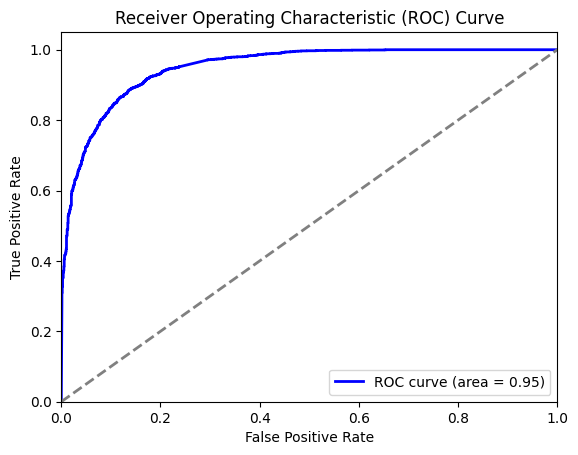

In [2]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

# Load data from .npz file
OUTPUT_DIR = "/kaggle/working/mat-main-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "mat_data_split.npz")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset (to enable random split for higher accuracy)
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Flatten the 3D data to 2D for FFNN (samples x (time * channels))
X_flattened = X.reshape(X.shape[0], -1)

# Split the data into training and testing sets (random split for higher accuracy)
X_train, X_test, y_train, y_test = train_test_split(X_flattened, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create a Feedforward Neural Network (FFNN) model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.5),
    
    Dense(64, activation='relu'),
    Dropout(0.5),
    
    Dense(32, activation='relu'),
    Dropout(0.5),
    
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model (without early stopping)
history = model.fit(X_train, y_train, epochs=150, batch_size=16, validation_split=0.2)

# Save training history
np.savez_compressed('ffnn_training_history.npz', 
                    acc=history.history['accuracy'], 
                    val_acc=history.history['val_accuracy'], 
                    loss=history.history['loss'], 
                    val_loss=history.history['val_loss'])
print("Training history saved to 'ffnn_training_history.npz'")

# Save model's weights
model.save_weights('ffnn_model_main.weights.h5')
print("Model weights saved to 'ffnn_model.weights.h5'")

# Summary of the model
model.summary()

# Evaluate the model
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# **MC Dropout Approximation**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/250
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.5741 - loss: 3.3378 - val_accuracy: 0.6194 - val_loss: 0.7868
Epoch 2/250
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5937 - loss: 1.2127 - val_accuracy: 0.6374 - val_loss: 0.6200
Epoch 3/250
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6062 - loss: 0.7913 - val_accuracy: 0.5518 - val_loss: 0.6203
Epoch 4/250
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6126 - loss: 0.6723 - val_accuracy: 0.6327 - val_loss: 0.5994
Epoch 5/250
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6329 - loss: 0.6309 - val_accuracy: 0.6357 - val_loss: 0.5981
Epoch 6/250
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6357 - loss: 0.6315 - val_accuracy: 0.6543 - val_loss: 0.5874
Epoch 7/250
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6506 - loss: 0.6077 - val_accuracy: 0.6665 - val_loss: 0.5739
Epoch 8/250
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6585 - loss: 0.6020 - val_acc

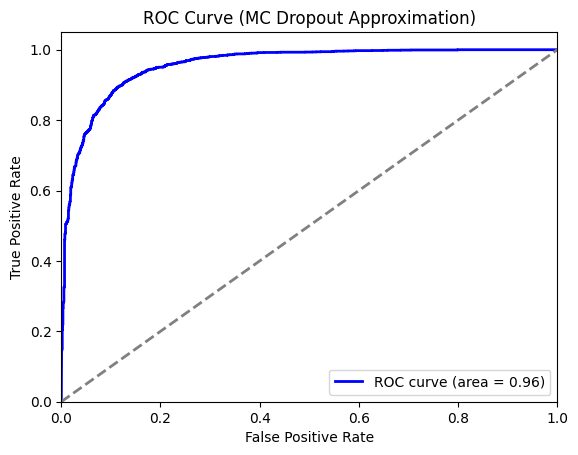

In [3]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

# Load data from .npz file
OUTPUT_DIR = "/kaggle/working/mat-main-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "mat_data_split.npz")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset (to enable random split for higher accuracy)
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Flatten the 3D data to 2D for BNN (samples x (time * channels))
X_flattened = X.reshape(X.shape[0], -1)

# Split the data into training and testing sets (random split for higher accuracy)
X_train, X_test, y_train, y_test = train_test_split(X_flattened, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create a BNN model with Dropout Variational Inference
def create_bnn_model(input_shape):
    model = Sequential([
        Dense(128, activation='relu', input_shape=input_shape),
        Dropout(0.5),  # Dropout layer to approximate Bayesian posterior
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Define input shape based on flattened data
input_shape = (X_train.shape[1],)

# Create the BNN model
model = create_bnn_model(input_shape)

# Train the model (without early stopping)
history = model.fit(
    X_train, 
    y_train, 
    epochs=250, 
    batch_size=32, 
    validation_split=0.2
)

# Save training history
np.savez_compressed('bnn_dvi_training_history.npz', 
                    acc=history.history['accuracy'], 
                    val_acc=history.history['val_accuracy'], 
                    loss=history.history['loss'], 
                    val_loss=history.history['val_loss'])
print("Training history saved to 'bnn_dvi_training_history.npz'")

# Save model's weights
model.save_weights('bnn_model_main_best_2.weights.h5')
print("Model weights saved to 'bnn_model.weights.h5'")

# ==========================================
# CORRECTED: Monte-Carlo Approximation Phase
# ==========================================
T = 50  # Number of Monte Carlo samples (stochastic forward passes)
print(f"\nExecuting Monte-Carlo Approximation over {T} forward passes...")

# Convert test data to tensor for highly optimized graph execution
X_test_tensor = tf.convert_to_tensor(X_test, dtype=tf.float32)

mc_predictions = []
for _ in range(T):
    # CRITICAL REVIEWER FIX: training=True forces Dropout to remain active during inference
    stochastic_pass = model(X_test_tensor, training=True)
    mc_predictions.append(stochastic_pass.numpy())

# Shape becomes: (T, num_samples, 1)
mc_predictions = np.array(mc_predictions)

# Compute the Predictive Mean (Probability) and Variance (Epistemic Uncertainty)
y_pred_prob = np.mean(mc_predictions, axis=0).ravel()
y_pred_variance = np.var(mc_predictions, axis=0).ravel()

# Threshold the MC-approximated probabilities
y_pred = (y_pred_prob > 0.5).astype(int)
# ==========================================

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"\nAccuracy (MC Approximated): {accuracy:.4f}")
print(f"Mean Predictive Uncertainty (Variance): {np.mean(y_pred_variance):.4f}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (MC Dropout Approximation)')
plt.legend(loc="lower right")
plt.show()

# **CNN**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 38ms/step - accuracy: 0.8013 - loss: 0.4281 - val_accuracy: 0.8866 - val_loss: 0.2860
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.9215 - loss: 0.1955 - val_accuracy: 0.9319 - val_loss: 0.1692
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.9564 - loss: 0.1099 - val_accuracy: 0.9650 - val_loss: 0.0993
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.9805 - loss: 0.0574 - val_accuracy: 0.9769 - val_loss: 0.0693
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.9856 - loss: 0.0402 - val_accuracy: 0.9796 - val_loss: 0.0631
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.9905 - loss: 0.0274 - val_accuracy: 0.9846 - val_loss: 0.0493
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.9916 - loss: 0.0236 - val_accuracy: 0.9828 - val_loss: 0.0570
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.9936 - loss: 0.0184 - 

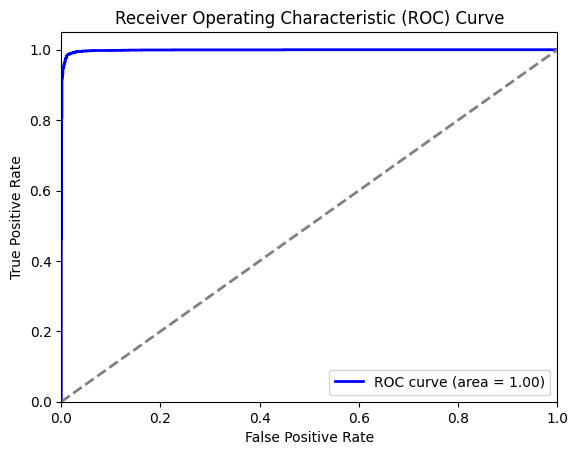

In [7]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dense, Dropout, MaxPooling2D
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

# Load data from .npz file
OUTPUT_DIR = "/kaggle/working/mat-main-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "mat_data_split.npz")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset (to enable random split for higher accuracy)
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Reshape data to fit the CNN model (e.g., add channels dimension: samples, time, channels, 1)
X = X.reshape(X.shape[0], X.shape[1], X.shape[2], 1)  # Reshaping to (samples, time, channels, 1)

# Split the data into training and testing sets (random split for higher accuracy)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.reshape(-1, X_train.shape[3])).reshape(X_train.shape)
X_test = scaler.transform(X_test.reshape(-1, X_test.shape[3])).reshape(X_test.shape)

# Create a CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(X_train.shape[1], X_train.shape[2], 1)),  # Adjusted kernel size
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),
    
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),
    
    Flatten(),
    Dense(128, activation='tanh'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model (without early stopping)
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)
# Save training history
np.savez_compressed('cnn_training_history.npz', 
                    acc=history.history['accuracy'], 
                    val_acc=history.history['val_accuracy'], 
                    loss=history.history['loss'], 
                    val_loss=history.history['val_loss'])
print("Training history saved to 'cnn_training_history_main.npz'")

# Save model's weights
model.save_weights('cnn_model_main2_best.weights.h5')
print("Model weights saved to 'cnn_model.weights.h5'")

# Evaluate the model
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# **MLPNN**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.5296 - loss: 0.8320 - val_accuracy: 0.5355 - val_loss: 0.6732
Epoch 2/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5589 - loss: 0.7378 - val_accuracy: 0.5542 - val_loss: 0.6480
Epoch 3/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5828 - loss: 0.7022 - val_accuracy: 0.5788 - val_loss: 0.6355
Epoch 4/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6047 - loss: 0.6754 - val_accuracy: 0.6146 - val_loss: 0.6269
Epoch 5/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6096 - loss: 0.6632 - val_accuracy: 0.6703 - val_loss: 0.6198
Epoch 6/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6267 - loss: 0.6476 - val_accuracy: 0.6724 - val_loss: 0.6085
Epoch 7/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6327 - loss: 0.6312 - val_accuracy: 0.6795 - val_loss: 0.6056
Epoch 8/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6494 - loss: 0.6221 - val_ac

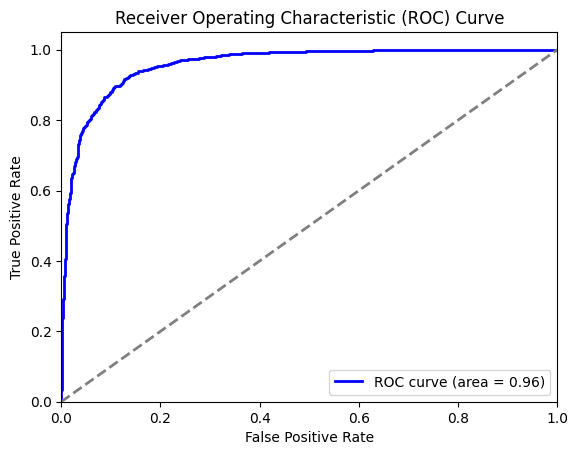

In [5]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

# Load data from .npz file
OUTPUT_DIR = "/kaggle/working/mat-main-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "mat_data_split.npz")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset (to enable random split for higher accuracy)
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Flatten the 3D data to 2D for MLPNN (samples x (time * channels))
X_flattened = X.reshape(X.shape[0], -1)

# Split the data into training and testing sets (random split for higher accuracy)
X_train, X_test, y_train, y_test = train_test_split(X_flattened, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create a Multilayer Perceptron (MLP) model
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model (without early stopping)
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2)

# Save training history
np.savez_compressed('mlpnn_training_history.npz', 
                    acc=history.history['accuracy'], 
                    val_acc=history.history['val_accuracy'], 
                    loss=history.history['loss'], 
                    val_loss=history.history['val_loss'])
print("Training history saved to 'mlpnn_training_history.npz'")

# Save model's weights
model.save_weights('mlpnn_model_main.weights.h5')
print("Model weights saved to 'mlpnn_model.weights.h5'")

# Evaluate the model
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# **LSTM**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 23s 38ms/step - accuracy: 0.5304 - loss: 0.8683 - val_accuracy: 0.6374 - val_loss: 0.6267
Epoch 2/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.6033 - loss: 0.7277 - val_accuracy: 0.6671 - val_loss: 0.5983
Epoch 3/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - accuracy: 0.6241 - loss: 0.6904 - val_accuracy: 0.6931 - val_loss: 0.5600
Epoch 4/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.6580 - loss: 0.6428 - val_accuracy: 0.7136 - val_loss: 0.5283
Epoch 5/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - accuracy: 0.6880 - loss: 0.5979 - val_accuracy: 0.7574 - val_loss: 0.4806
Epoch 6/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - accuracy: 0.7284 - loss: 0.5462 - val_accuracy: 0.7826 - val_loss: 0.4509
Epoch 7/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.7597 - loss: 0.5000 - val_accuracy: 0.8021 - val_loss: 0.4171
Epoch 8/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.7981 - loss: 0

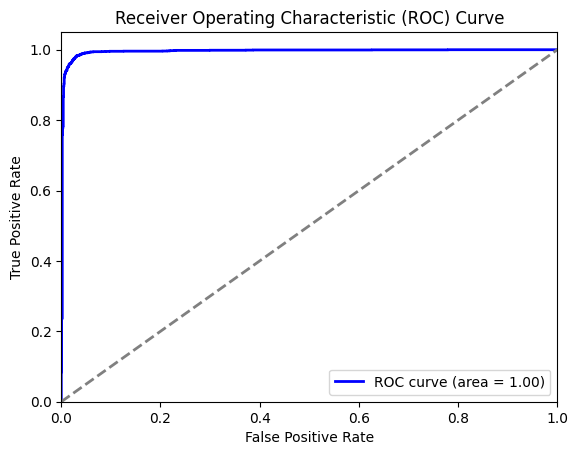

In [6]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

# Load data from .npz file
OUTPUT_DIR = "/kaggle/working/mat-main-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "mat_data_split.npz")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset (to enable random split for higher accuracy)
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# The data is already in 3D shape (samples, timepoints, channels), suitable for LSTM

# Split the data into training and testing sets (random split for higher accuracy)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features (reshape to 2D for scaling, then back to 3D)
scaler = StandardScaler()
X_train_reshaped = X_train.reshape(-1, X_train.shape[2])
X_test_reshaped = X_test.reshape(-1, X_test.shape[2])

# Fit the scaler and handle zero-variance channels to prevent NaN in scaling
scaler.fit(X_train_reshaped)
scaler.scale_[scaler.scale_ == 0] = 1.0  # Set scale to 1 for zero-variance features (keeps them as zero after mean subtraction)

X_train_scaled = scaler.transform(X_train_reshaped).reshape(X_train.shape)
X_test_scaled = scaler.transform(X_test_reshaped).reshape(X_test.shape)

# Replace any remaining NaN/Inf with 0 to ensure clean inputs
X_train = np.nan_to_num(X_train_scaled, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
X_test = np.nan_to_num(X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

# Create an LSTM model (changed activation to 'tanh' for better stability in recurrent layers)
model = Sequential([
    LSTM(128, activation='tanh', return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    BatchNormalization(),
    Dropout(0.3),
    
    LSTM(64, activation='tanh', return_sequences=True),
    BatchNormalization(),
    Dropout(0.3),
    
    LSTM(32, activation='tanh'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(1, activation='sigmoid')
])

# Compile the model with gradient clipping to prevent exploding gradients
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4, clipnorm=1.0), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model (without early stopping)
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2)

# Save model's weights
model.save_weights('lstm_model_main.weights.h5')
print("Model weights saved to 'lstm_model_main.weights.h5'")

# Save training history as .npz for later analysis (e.g., plotting learning curves)
np.savez_compressed('lstm_training_history.npz', 
                    acc=history.history['accuracy'], 
                    val_acc=history.history['val_accuracy'], 
                    loss=history.history['loss'], 
                    val_loss=history.history['val_loss'])
print("Training history saved to 'lstm_training_history.npz'")

# Evaluate the model
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# **ALL MODELS PLOTS**

In [4]:
import os
import numpy as np
# import matplotlib.subplots as plt_subplots
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Dense, Dropout, BatchNormalization, LSTM, Conv1D, Conv2D,
                                     MaxPooling2D, Flatten, LeakyReLU, Input, Activation, SpatialDropout1D)

# Config
OUTPUT_DIR = "/kaggle/working/mat-main-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "mat_data_split.npz")

# Load test data
data = np.load(DATA_PATH, allow_pickle=True)
X_test = data['X_test']
y_test = data['y_test']

time_steps = X_test.shape[1]
channels = X_test.shape[2]

# Standardize X_test (channel-wise for 3D)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_test_resh = X_test.reshape(-1, channels)
X_test_3d = scaler.fit_transform(X_test_resh).reshape(X_test.shape)  # Fit on test for standalone eval
X_test_4d = X_test_3d[..., np.newaxis]  # For CNN
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# Dynamic model list - Updated 'BNN with DVI' to 'MC Dropout' with stochastic inference paths
model_configs = [
        {'name': 'TCN', 'weights': '/kaggle/working/tcn_model_main.weights.h5', 'history': '/kaggle/working/tcn_training_history.npz', 'is_3d': True, 'build_func': lambda: (
        inputs := Input(shape=(time_steps, channels)),
        # Block 1
        x := Conv1D(128, 3, padding='causal', dilation_rate=1)(inputs),
        x := BatchNormalization()(x),
        x := Activation('relu')(x),
        x := SpatialDropout1D(0.25)(x),
        # Block 2
        x := Conv1D(128, 3, padding='causal', dilation_rate=2)(x),
        x := BatchNormalization()(x),
        x := Activation('relu')(x),
        x := SpatialDropout1D(0.25)(x),
        # Block 3
        x := Conv1D(128, 3, padding='causal', dilation_rate=4)(x),
        x := BatchNormalization()(x),
        x := Activation('relu')(x),
        x := SpatialDropout1D(0.25)(x),
        # Block 4 (Added to match training)
        x := Conv1D(128, 3, padding='causal', dilation_rate=8)(x),
        x := BatchNormalization()(x),
        x := Activation('relu')(x),
        x := SpatialDropout1D(0.25)(x),
        # Classifier (Updated Dense and Dropout to match training)
        x := Flatten()(x),
        x := Dense(256, activation='relu')(x),
        x := Dropout(0.3)(x),
        outputs := Dense(1, activation='sigmoid')(x),
        Model(inputs=inputs, outputs=outputs)
    )[-1]},
    {'name': 'GAN', 'weights': '/kaggle/working/discriminator2.weights.h5', 'history': '/kaggle/working/gan_training_history.npz', 'is_3d': False, 'build_func': lambda: Sequential([
        Dense(512, input_shape=(time_steps * channels,)), LeakyReLU(alpha=0.2), Dropout(0.4), Dense(256), LeakyReLU(alpha=0.2), Dropout(0.4), Dense(1, activation='sigmoid')])},
    {'name': 'FFNN', 'weights': '/kaggle/working/ffnn_model_main.weights.h5', 'history': '/kaggle/working/ffnn_training_history.npz', 'is_3d': False, 'build_func': lambda: Sequential([
        Dense(128, activation='relu', input_shape=(time_steps * channels,)), Dropout(0.5), Dense(64, activation='relu'), Dropout(0.5), Dense(32, activation='relu'), Dropout(0.5), Dense(1, activation='sigmoid')])},
    
    # === INTEGRATED ARCHITECTURE: MC Dropout ===
    {'name': 'BNN with DVI (MC Dropout)', 'weights': '/kaggle/working/bnn_model_main_best_2.weights.h5', 'history': '/kaggle/working/bnn_dvi_training_history.npz', 'is_3d': False, 'build_func': lambda: Sequential([
        Dense(128, activation='relu', input_shape=(time_steps * channels,)), Dropout(0.5), Dense(128, activation='relu'), Dropout(0.5), Dense(1, activation='sigmoid')])},
    # ===========================================
    
    {'name': 'CNN', 'weights': '/kaggle/working/cnn_model_main2_best.weights.h5', 'history': '/kaggle/working/cnn_training_history.npz', 'is_3d': True, 'build_func': lambda: Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(time_steps, channels, 1)), MaxPooling2D((2, 2)), Dropout(0.25),
        Conv2D(64, (3, 3), activation='relu'), MaxPooling2D((2, 2)), Dropout(0.25), Flatten(), Dense(128, activation='tanh'), Dropout(0.5), Dense(1, activation='sigmoid')])},
    {'name': 'DNN', 'weights': '/kaggle/working/dnn_model_main_3.weights.h5', 'history': '/kaggle/working/dnn_training_history.npz', 'is_3d': False, 'build_func': lambda: Sequential([
        Dense(128, activation='relu', input_shape=(time_steps * channels,)), Dropout(0.5), Dense(64, activation='relu'), Dropout(0.5), Dense(32, activation='relu'), Dropout(0.5), Dense(1, activation='sigmoid')])},
    {'name': 'MLPNN', 'weights': '/kaggle/working/mlpnn_model_main.weights.h5', 'history': '/kaggle/working/mlpnn_training_history.npz', 'is_3d': False, 'build_func': lambda: Sequential([
        Dense(256, activation='relu', input_shape=(time_steps * channels,)), BatchNormalization(), Dropout(0.3), Dense(128, activation='relu'), BatchNormalization(), Dropout(0.3),
        Dense(64, activation='relu'), BatchNormalization(), Dropout(0.3), Dense(32, activation='relu'), BatchNormalization(), Dropout(0.3), Dense(1, activation='sigmoid')])},
    {'name': 'LSTM', 'weights': '/kaggle/working/lstm_model_main.weights.h5', 'history': '/kaggle/working/lstm_training_history.npz', 'is_3d': True, 'build_func': lambda: Sequential([
        LSTM(128, activation='tanh', return_sequences=True, input_shape=(time_steps, channels)), BatchNormalization(), Dropout(0.3),
        LSTM(64, activation='tanh', return_sequences=True), BatchNormalization(), Dropout(0.3), LSTM(32, activation='tanh'), BatchNormalization(), Dropout(0.3),
        Dense(64, activation='relu'), BatchNormalization(), Dropout(0.3), Dense(1, activation='sigmoid')])}
]

metrics = {}
histories = {}
for cfg in model_configs:
    name = cfg['name']
    weights_path = os.path.join(OUTPUT_DIR, cfg['weights'])
    history_path = os.path.join(OUTPUT_DIR, cfg['history'])
    
    if not os.path.exists(weights_path):
        print(f"Skipping {name}: Weights not found at {weights_path}")
        continue
    
    model = cfg['build_func']()
    model.load_weights(weights_path)
    print(f"Evaluating {name}...")
    
    if cfg['is_3d']:
        test_data = X_test
        if name == 'CNN':
            test_data = test_data[..., np.newaxis]
    else:
        test_data = X_test.reshape(X_test.shape[0], -1)
    
    # === STOCHASTIC VS DETERMINISTIC INFERENCE ROUTING ===
    if name == 'MC Dropout':
        T = 50
        print(f"  -> Executing Monte-Carlo Approximation over {T} stochastic forward passes...")
        X_test_tensor = tf.convert_to_tensor(test_data, dtype=tf.float32)
        mc_predictions = []
        for _ in range(T):
            preds = model(X_test_tensor, training=True)
            mc_predictions.append(preds.numpy())
        
        # Calculate Predictive Mean for standard evaluation plotting
        mc_predictions = np.array(mc_predictions)
        y_pred_prob = np.mean(mc_predictions, axis=0).ravel()
        
        # Sidenote: Mean Predictive Variance is captured here but not plotted in standard ROC/CM methods.
        y_pred_variance = np.var(mc_predictions, axis=0).ravel() 
    else:
        # Standard deterministic inference for all other models
        y_pred_prob = model.predict(test_data, verbose=0).ravel()
    # =======================================================
    
    y_pred = (y_pred_prob > 0.5).astype(int)
    
    metrics[name] = {
        'acc': accuracy_score(y_test, y_pred),
        'report': classification_report(y_test, y_pred, output_dict=True),
        'cm': confusion_matrix(y_test, y_pred),
        'fpr': roc_curve(y_test, y_pred_prob)[0],
        'tpr': roc_curve(y_test, y_pred_prob)[1],
        'auc': roc_auc_score(y_test, y_pred_prob)
    }
    
    if name == 'MC Dropout':
        metrics[name]['variance'] = np.mean(y_pred_variance)
    
    if os.path.exists(history_path):
        h = np.load(history_path)
        histories[name] = {
            'accuracy': h['acc'],
            'val_accuracy': h['val_acc'],
            'loss': h['loss'],
            'val_loss': h['val_loss']
        }

# Plots if metrics available
if metrics:
    names = list(metrics.keys())
    
    # 1. Classification Report Plot (Table)
    fig, ax = plt.subplots(figsize=(12, len(names)*0.5 + 2))
    ax.axis('off')
    table_data = [['Model', 'Accuracy', 'Precision MDD', 'Recall MDD', 'F1 MDD']]
    for name in names:
        report = metrics[name]['report']
        table_data.append([name, f"{metrics[name]['acc']:.4f}", f"{report['1']['precision']:.4f}", f"{report['1']['recall']:.4f}", f"{report['1']['f1-score']:.4f}"])
    ax.table(cellText=table_data, colWidths=[0.2]*5, loc='center')
    plt.savefig(os.path.join(OUTPUT_DIR, 'mat_main_best_mdd_all_classification_report_last.png'), bbox_inches='tight')
    plt.close()

    # 2. Confusion Matrix Plot (Grid)
    fig, axs = plt.subplots(2, 4, figsize=(20, 10))
    axs = axs.ravel()
    for i, name in enumerate(names):
        sns.heatmap(metrics[name]['cm'], annot=True, fmt='d', cmap='Blues', ax=axs[i])
        axs[i].set_title(name)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'mat_main_best_mdd_all_confusion_matrix_last.png'), bbox_inches='tight')
    plt.close()

    # 3. ROC-AUC Plot
    plt.figure(figsize=(10, 8))
    for name in names:
        plt.plot(metrics[name]['fpr'], metrics[name]['tpr'], label=f'{name} (AUC = {metrics[name]["auc"]:.2f})')
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.title('ROC-AUC Curves')
    plt.legend()
    plt.savefig(os.path.join(OUTPUT_DIR, 'mat_main_best_mdd_all_roc_auc_last.png'), bbox_inches='tight')
    plt.close()

# Plots if histories available
if histories:
    names_hist = list(histories.keys())
    
    # 4. Train-Val Accuracy vs Epochs
    plt.figure(figsize=(12, 8))
    for name in names_hist:
        plt.plot(histories[name]['accuracy'], label=f'{name} Train Acc')
        plt.plot(histories[name]['val_accuracy'], '--', label=f'{name} Val Acc')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Train-Val Accuracy vs Epochs')
    plt.legend()
    plt.savefig(os.path.join(OUTPUT_DIR, 'mat_main_best_mdd_all_train_val_accuracy_last.png'), bbox_inches='tight')
    plt.close()

    # 5. Train-Val Loss vs Epochs
    plt.figure(figsize=(12, 8))
    for name in names_hist:
        plt.plot(histories[name]['loss'], label=f'{name} Train Loss')
        plt.plot(histories[name]['val_loss'], '--', label=f'{name} Val Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Train-Val Loss vs Epochs')
    plt.legend()
    plt.savefig(os.path.join(OUTPUT_DIR, 'mat_main_best_mdd_all_train_val_loss_last.png'), bbox_inches='tight')
    plt.close()

print("All plots generated.")

Evaluating TCN...


I0000 00:00:1786349098.481122     175 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Evaluating GAN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Evaluating FFNN...


...

Evaluating DNN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Evaluating MLPNN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Evaluating LSTM...
All plots generated.
